In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 5")

## Section 1 : Import Necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Color palette
COLORS = {'Yes': '#E74C3C', 'No': '#2ECC71', 'pos': '#E74C3C', 'neg': '#2ECC71'}
print('Libraries loaded successfully')

Libraries loaded successfully


## Section 2 : Load Data

In [5]:
# Load the dataset
df = pd.read_csv(r"D:\FQL\PJ 5\osteoporosis.csv")

In [6]:
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset Shape: 1958 rows × 16 columns


In [7]:
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [8]:
# Drop ID column
df.drop(columns=['ID'], inplace=True, errors='ignore')

In [9]:
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [10]:
#df['Osteoporosis'] = df['Osteoporosis'].map({'Yes': 1, 'No': 0})

## Section 3 : Data Overview

In [11]:
print('DATASET INFO')
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporosis         1958 non-null   int64

In [12]:
print('\n--- Statistical Summary (Numerical) ---')
df.describe()


--- Statistical Summary (Numerical) ---


,Id,Age,Osteoporosis
count,1958.000000,1958.000000,1958.000000
mean,105515.320735,39.101124,0.500000
std,2589.407806,21.355424,0.500128
min,101008.000000,18.000000,0.000000
25%,103348.500000,21.000000,0.000000
50%,105469.000000,32.000000,0.500000
75%,107755.000000,53.000000,1.000000
max,109996.000000,90.000000,1.000000


In [13]:
print('\n--- Statistical Summary (Categorical) ---')
df.describe(include='object')


--- Statistical Summary (Categorical) ---


,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures
count,1958,1958,1958,1958,1958,1958,1958,1958,1958,970,1311,973,1958
unique,2,2,2,3,2,2,2,2,2,1,2,1,2
top,Male,Normal,No,African American,Normal,Low,Sufficient,Active,Yes,Moderate,Hyperthyroidism,Corticosteroids,Yes
freq,992,981,998,681,1027,1004,1011,1021,982,970,678,973,983


In [14]:
report = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulls':   df.isnull().sum(),
    'null_%':  (df.isnull().mean()*100).round(2),
    'unique':  df.nunique(),
})

In [15]:
print('======= Quality Report =======')
display(report)
print(f'Duplicate rows: {df.duplicated().sum()}')

======= Quality Report =======


,dtype,nulls,null_%,unique
Id,int64,0,0.00,1749
Age,int64,0,0.00,73
Gender,object,0,0.00,2
Hormonal Changes,object,0,0.00,2
Family History,object,0,0.00,2
Race/Ethnicity,object,0,0.00,3
Body Weight,object,0,0.00,2
Calcium Intake,object,0,0.00,2
Vitamin D Intake,object,0,0.00,2
Physical Activity,object,0,0.00,2


Duplicate rows: 0


## Section 4 : Missing Values Analysis

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

                     Missing Count  Missing %
Alcohol Consumption            988  50.459653
Medical Conditions             647  33.043922
Medications                    985  50.306435


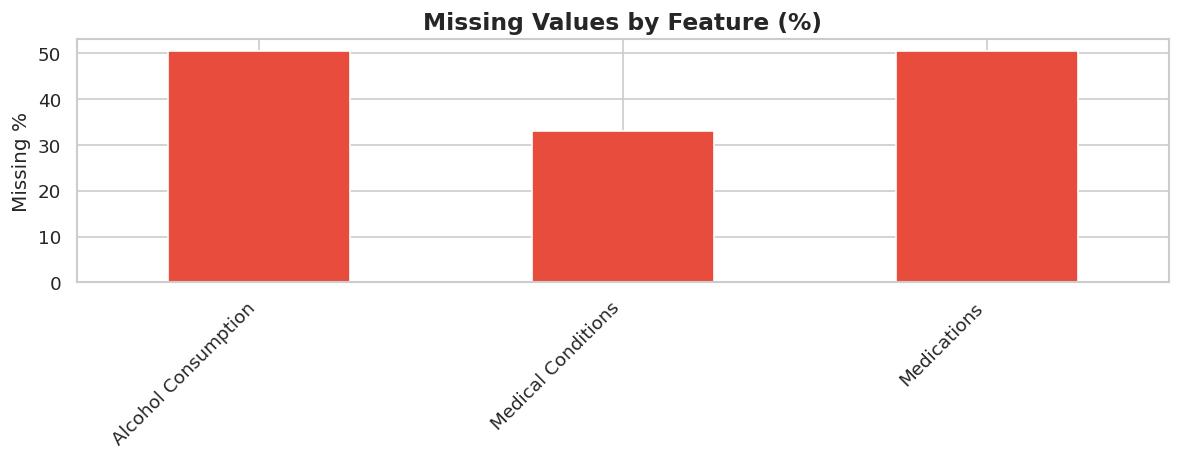

In [19]:
if missing_df.empty:
    print('No missing values found in the dataset!')
else:
    print(missing_df)
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='#E74C3C')
    ax.set_title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.savefig('plot/00_Missing values.png', bbox_inches = 'tight')
    plt.tight_layout()
    plt.show()

## section 5 : Target Variable distribution

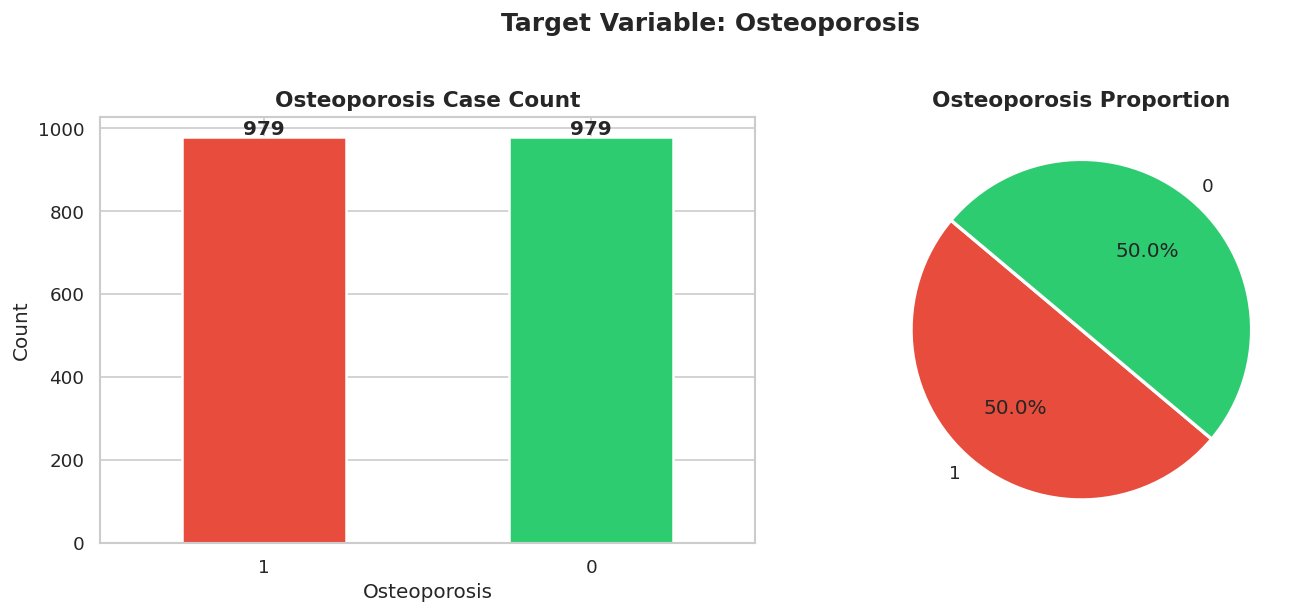

Class Distribution:
Osteoporosis
1    50.0
0    50.0
Name: proportion, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['Osteoporosis'].value_counts()
target_pct = df['Osteoporosis'].value_counts(normalize=True) * 100

# Bar chart
colors = ['#E74C3C' if x == 1 else '#2ECC71' for x in target_counts.index]
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Osteoporosis Case Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Osteoporosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=['#E74C3C', '#2ECC71'], startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Osteoporosis Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Osteoporosis', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('plot/01_target_variable.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f'Class Distribution:\n{target_pct.round(2)}')

## Section 6 : Univariate Analysis

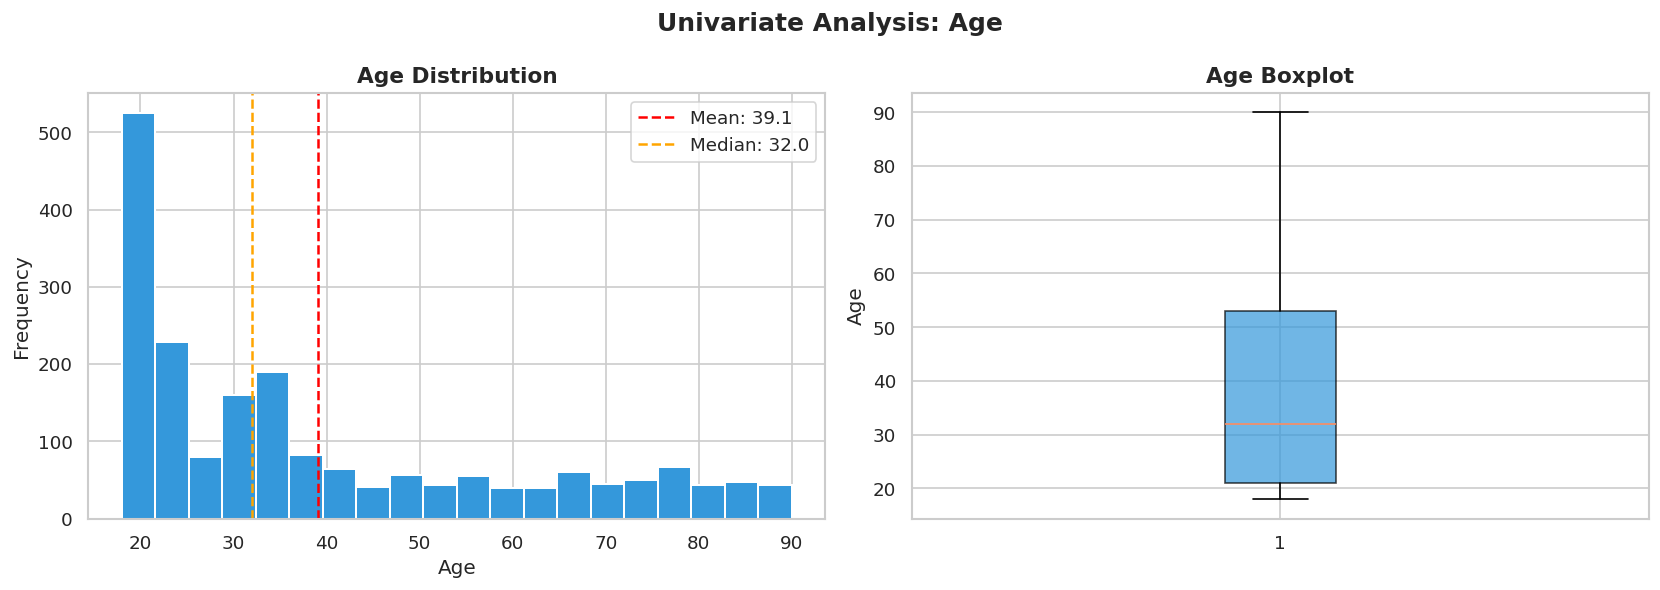

In [21]:
# --- Age Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=20, color='#3498DB', edgecolor='white', linewidth=1.2)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='orange', linestyle='--', label=f'Median: {df["Age"].median():.1f}')
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['Age'], patch_artist=True, boxprops=dict(facecolor='#3498DB', alpha=0.7))
axes[1].set_title('Age Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Age')

plt.suptitle('Univariate Analysis: Age', fontsize=15, fontweight='bold')
plt.savefig('plot/02_age_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

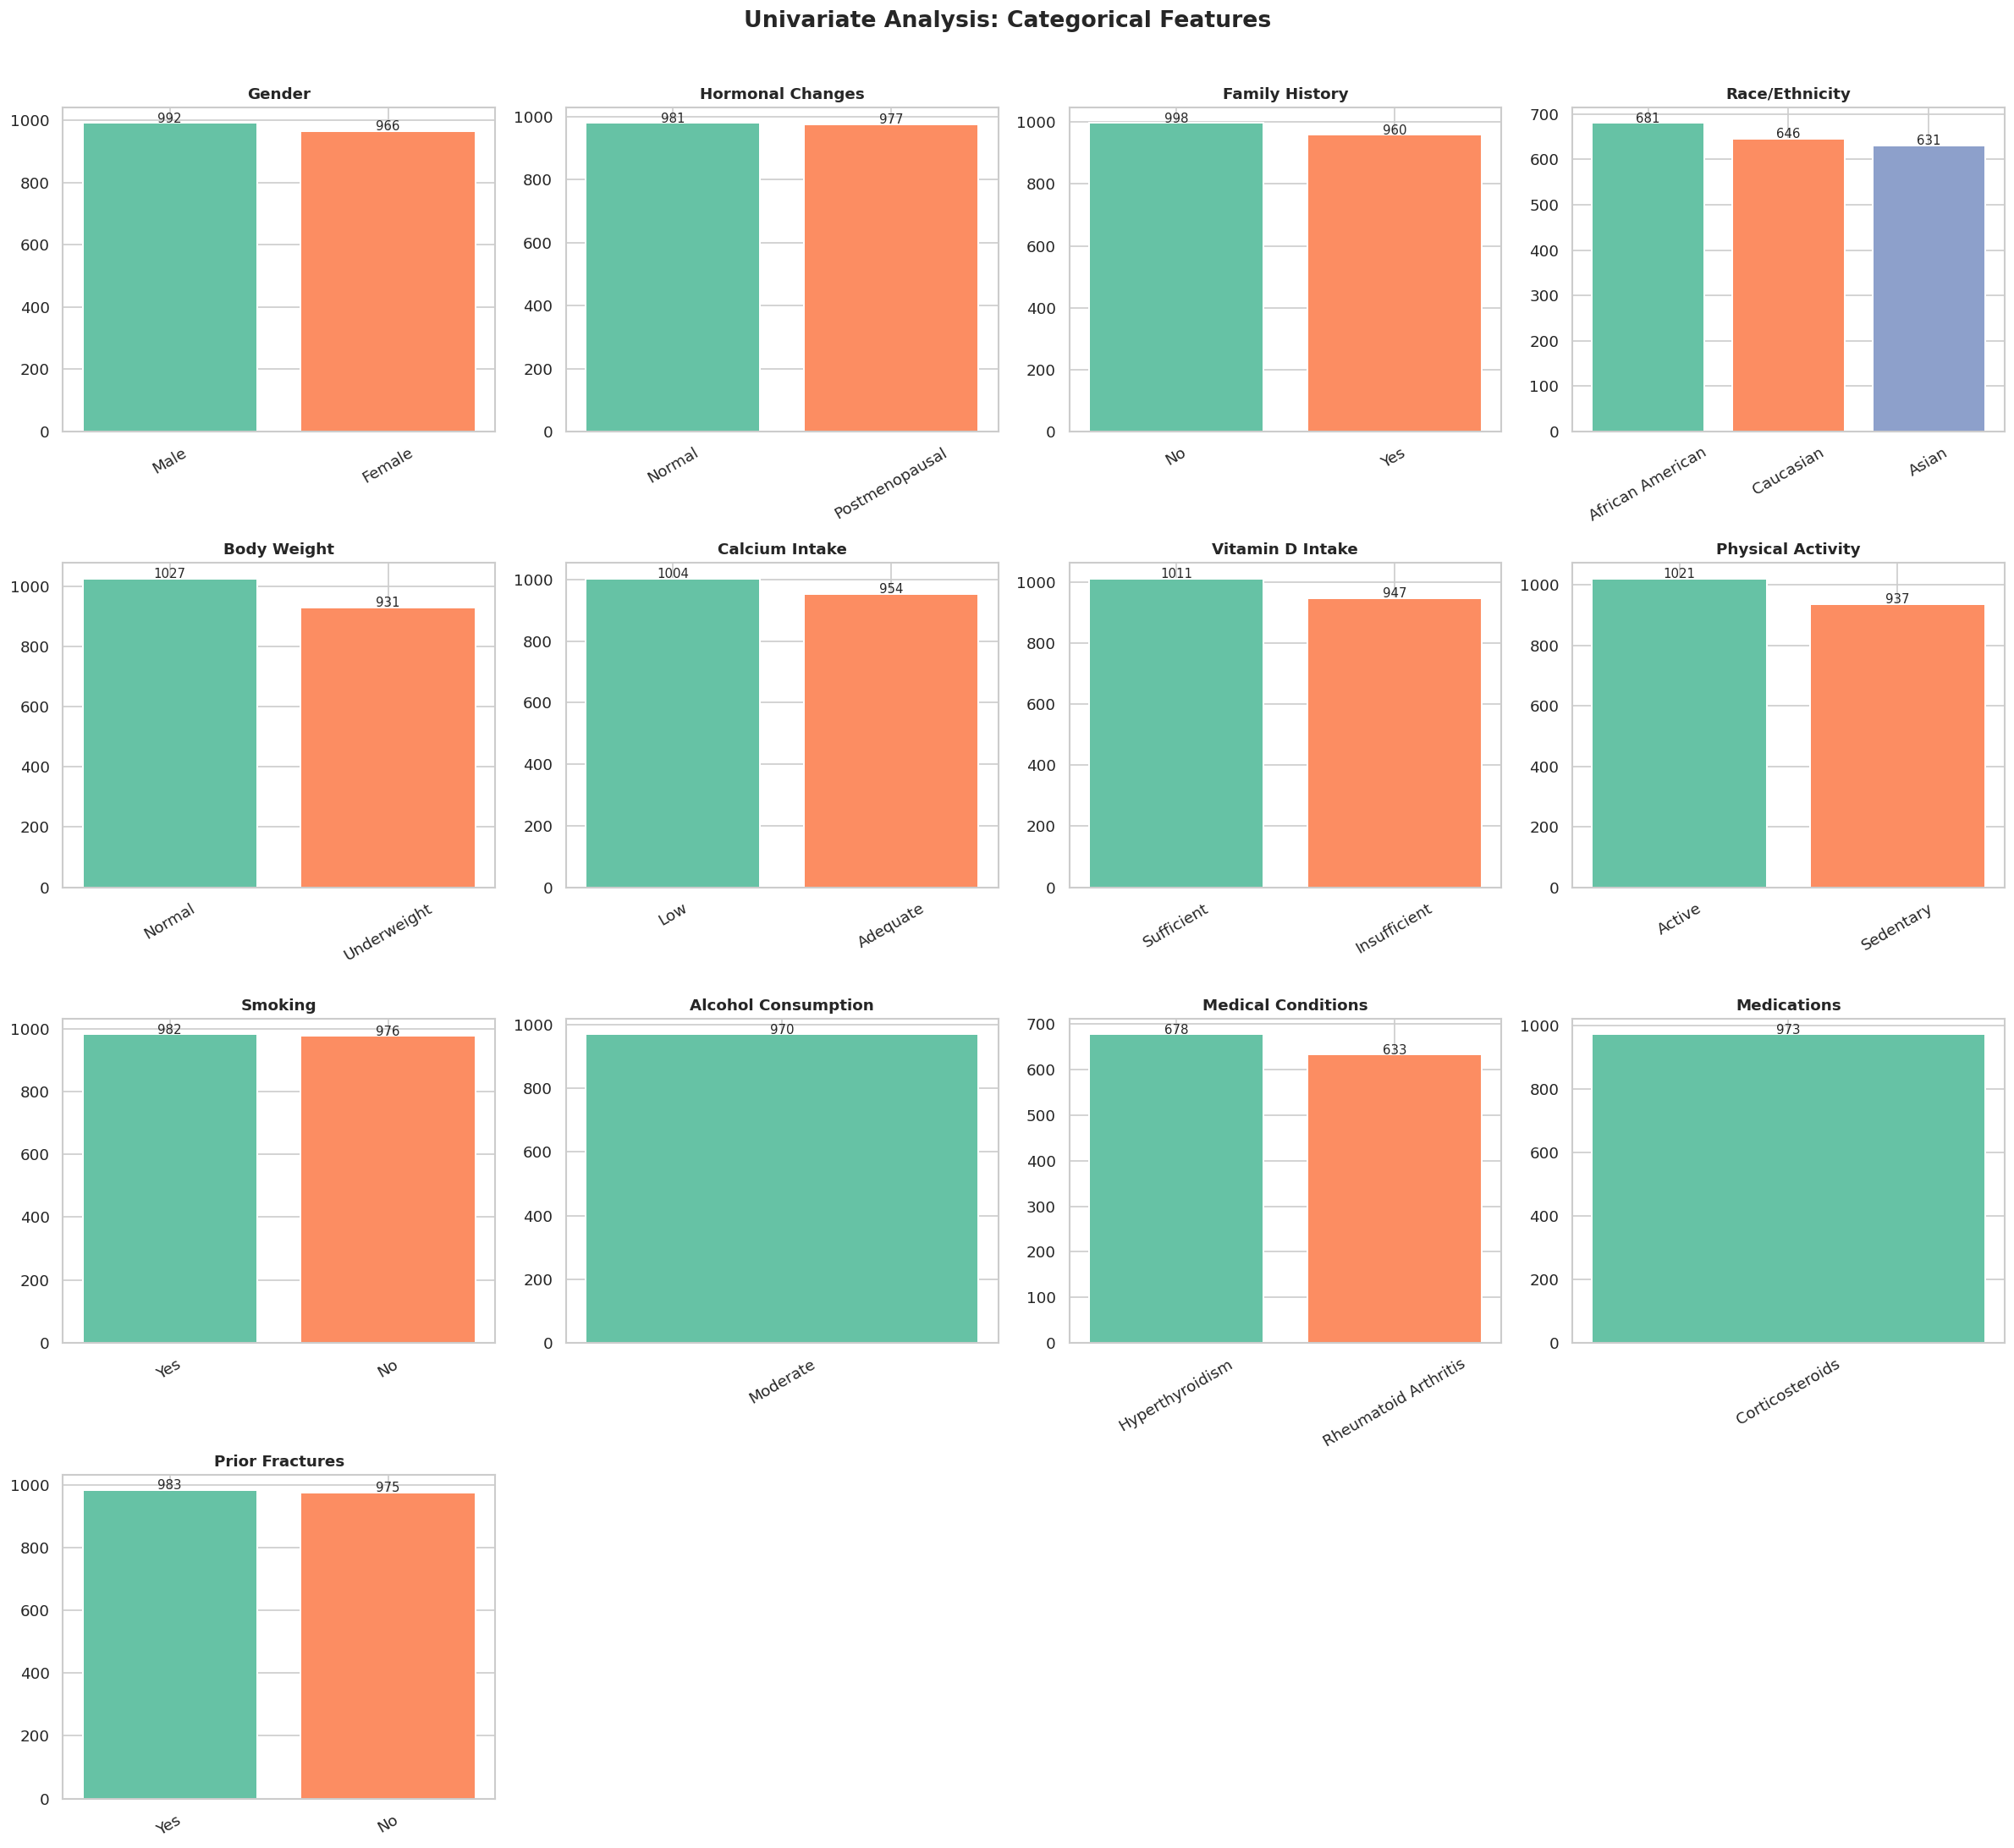

In [22]:
# --- Categorical Features Distribution ---
cat_cols = ['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
            'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity',
            'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    val_counts = df[col].value_counts()
    axes[i].bar(val_counts.index, val_counts.values,
                color=sns.color_palette('Set2', len(val_counts)),
                edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(val_counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=9)

# Hide unused subplots
for k in range(len(cat_cols), len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Univariate Analysis: Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('plot/03_categorical_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 7 : Bivariate Analysis

#### Feature vs Osteoporsis

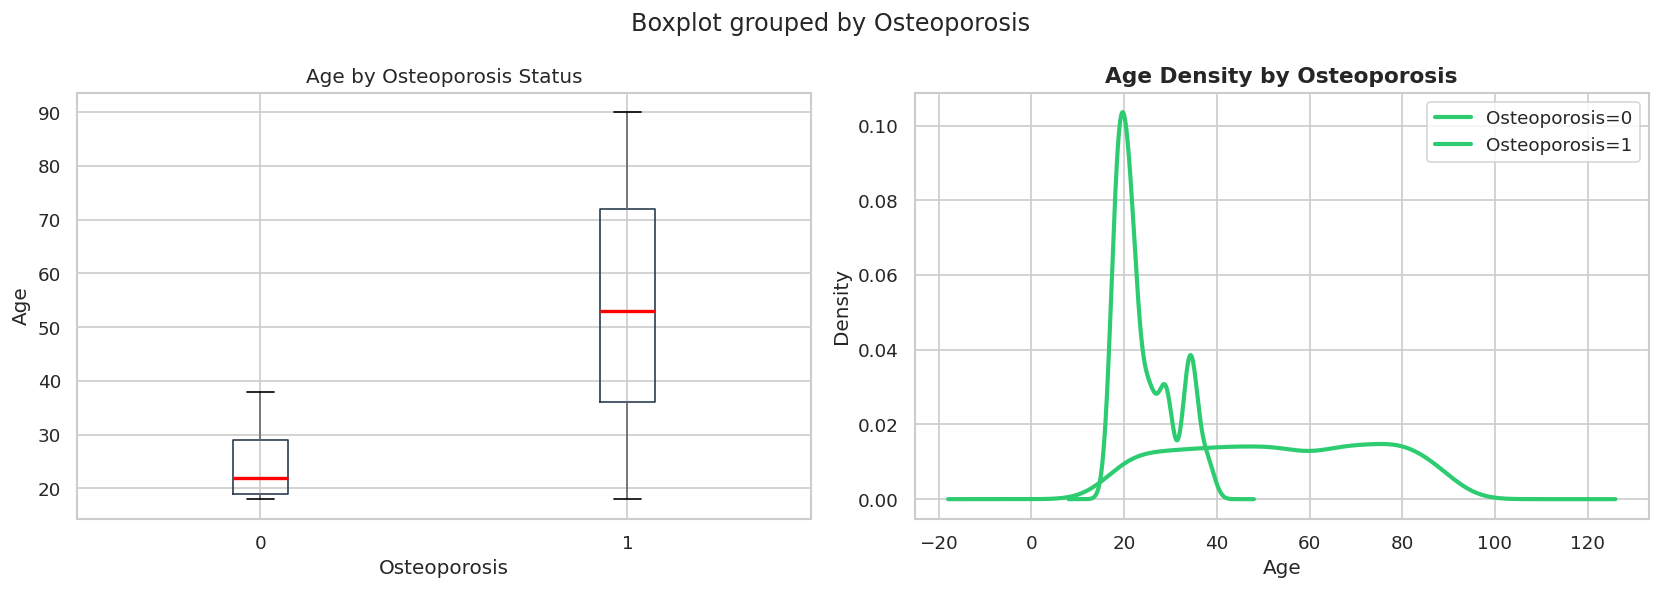

In [23]:
# --- Age vs Osteoporosis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='Age', by='Osteoporosis', ax=axes[0],
           boxprops=dict(color='#2C3E50'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Age by Osteoporosis Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Osteoporosis')
axes[0].set_ylabel('Age')
plt.sca(axes[0])
plt.title('Age by Osteoporosis Status')

# KDE plot
for label, grp in df.groupby('Osteoporosis')['Age']:
    color = '#E74C3C' if label == 'Yes' else '#2ECC71'
    grp.plot.kde(ax=axes[1], label=f'Osteoporosis={label}', color=color, linewidth=2.5)
axes[1].set_title('Age Density by Osteoporosis', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('Age')

plt.savefig('plot/04_bivariate_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [25]:
# T-test
yes_age = df[df['Osteoporosis'] == 1]['Age']
no_age  = df[df['Osteoporosis'] == 0]['Age']
t_stat, p_val = stats.ttest_ind(yes_age, no_age)
print(f'Mean Age (Osteoporosis=Yes): {yes_age.mean():.2f}')
print(f'Mean Age (Osteoporosis=No):  {no_age.mean():.2f}')
print(f'T-test → t={t_stat:.3f}, p={p_val:.4f} {"(Significant )" if p_val < 0.05 else "(Not Significant)"}')

Mean Age (Osteoporosis=Yes): 53.86
Mean Age (Osteoporosis=No):  24.34
T-test → t=42.306, p=0.0000 (Significant )


###### Note
'''
data might be biased or imbalanced
lekage might be there
'''

In [26]:
df.groupby('Osteoporosis')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Osteoporosis,,,,,,,,
0,979.0,24.343207,6.108987,18.0,19.0,22.0,29.0,38.0
1,979.0,53.859040,20.957512,18.0,36.0,53.0,72.0,90.0


<Axes: xlabel='Osteoporosis', ylabel='Age'>

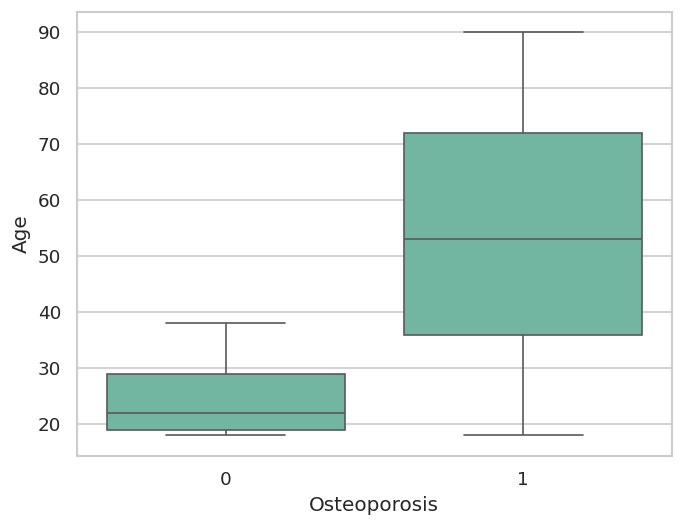

In [27]:
sns.boxplot(x='Osteoporosis', y='Age', data=df)

In [28]:
df['Osteoporosis'].value_counts()

Osteoporosis
1    979
0    979
Name: count, dtype: int64

might be weak when testing or training

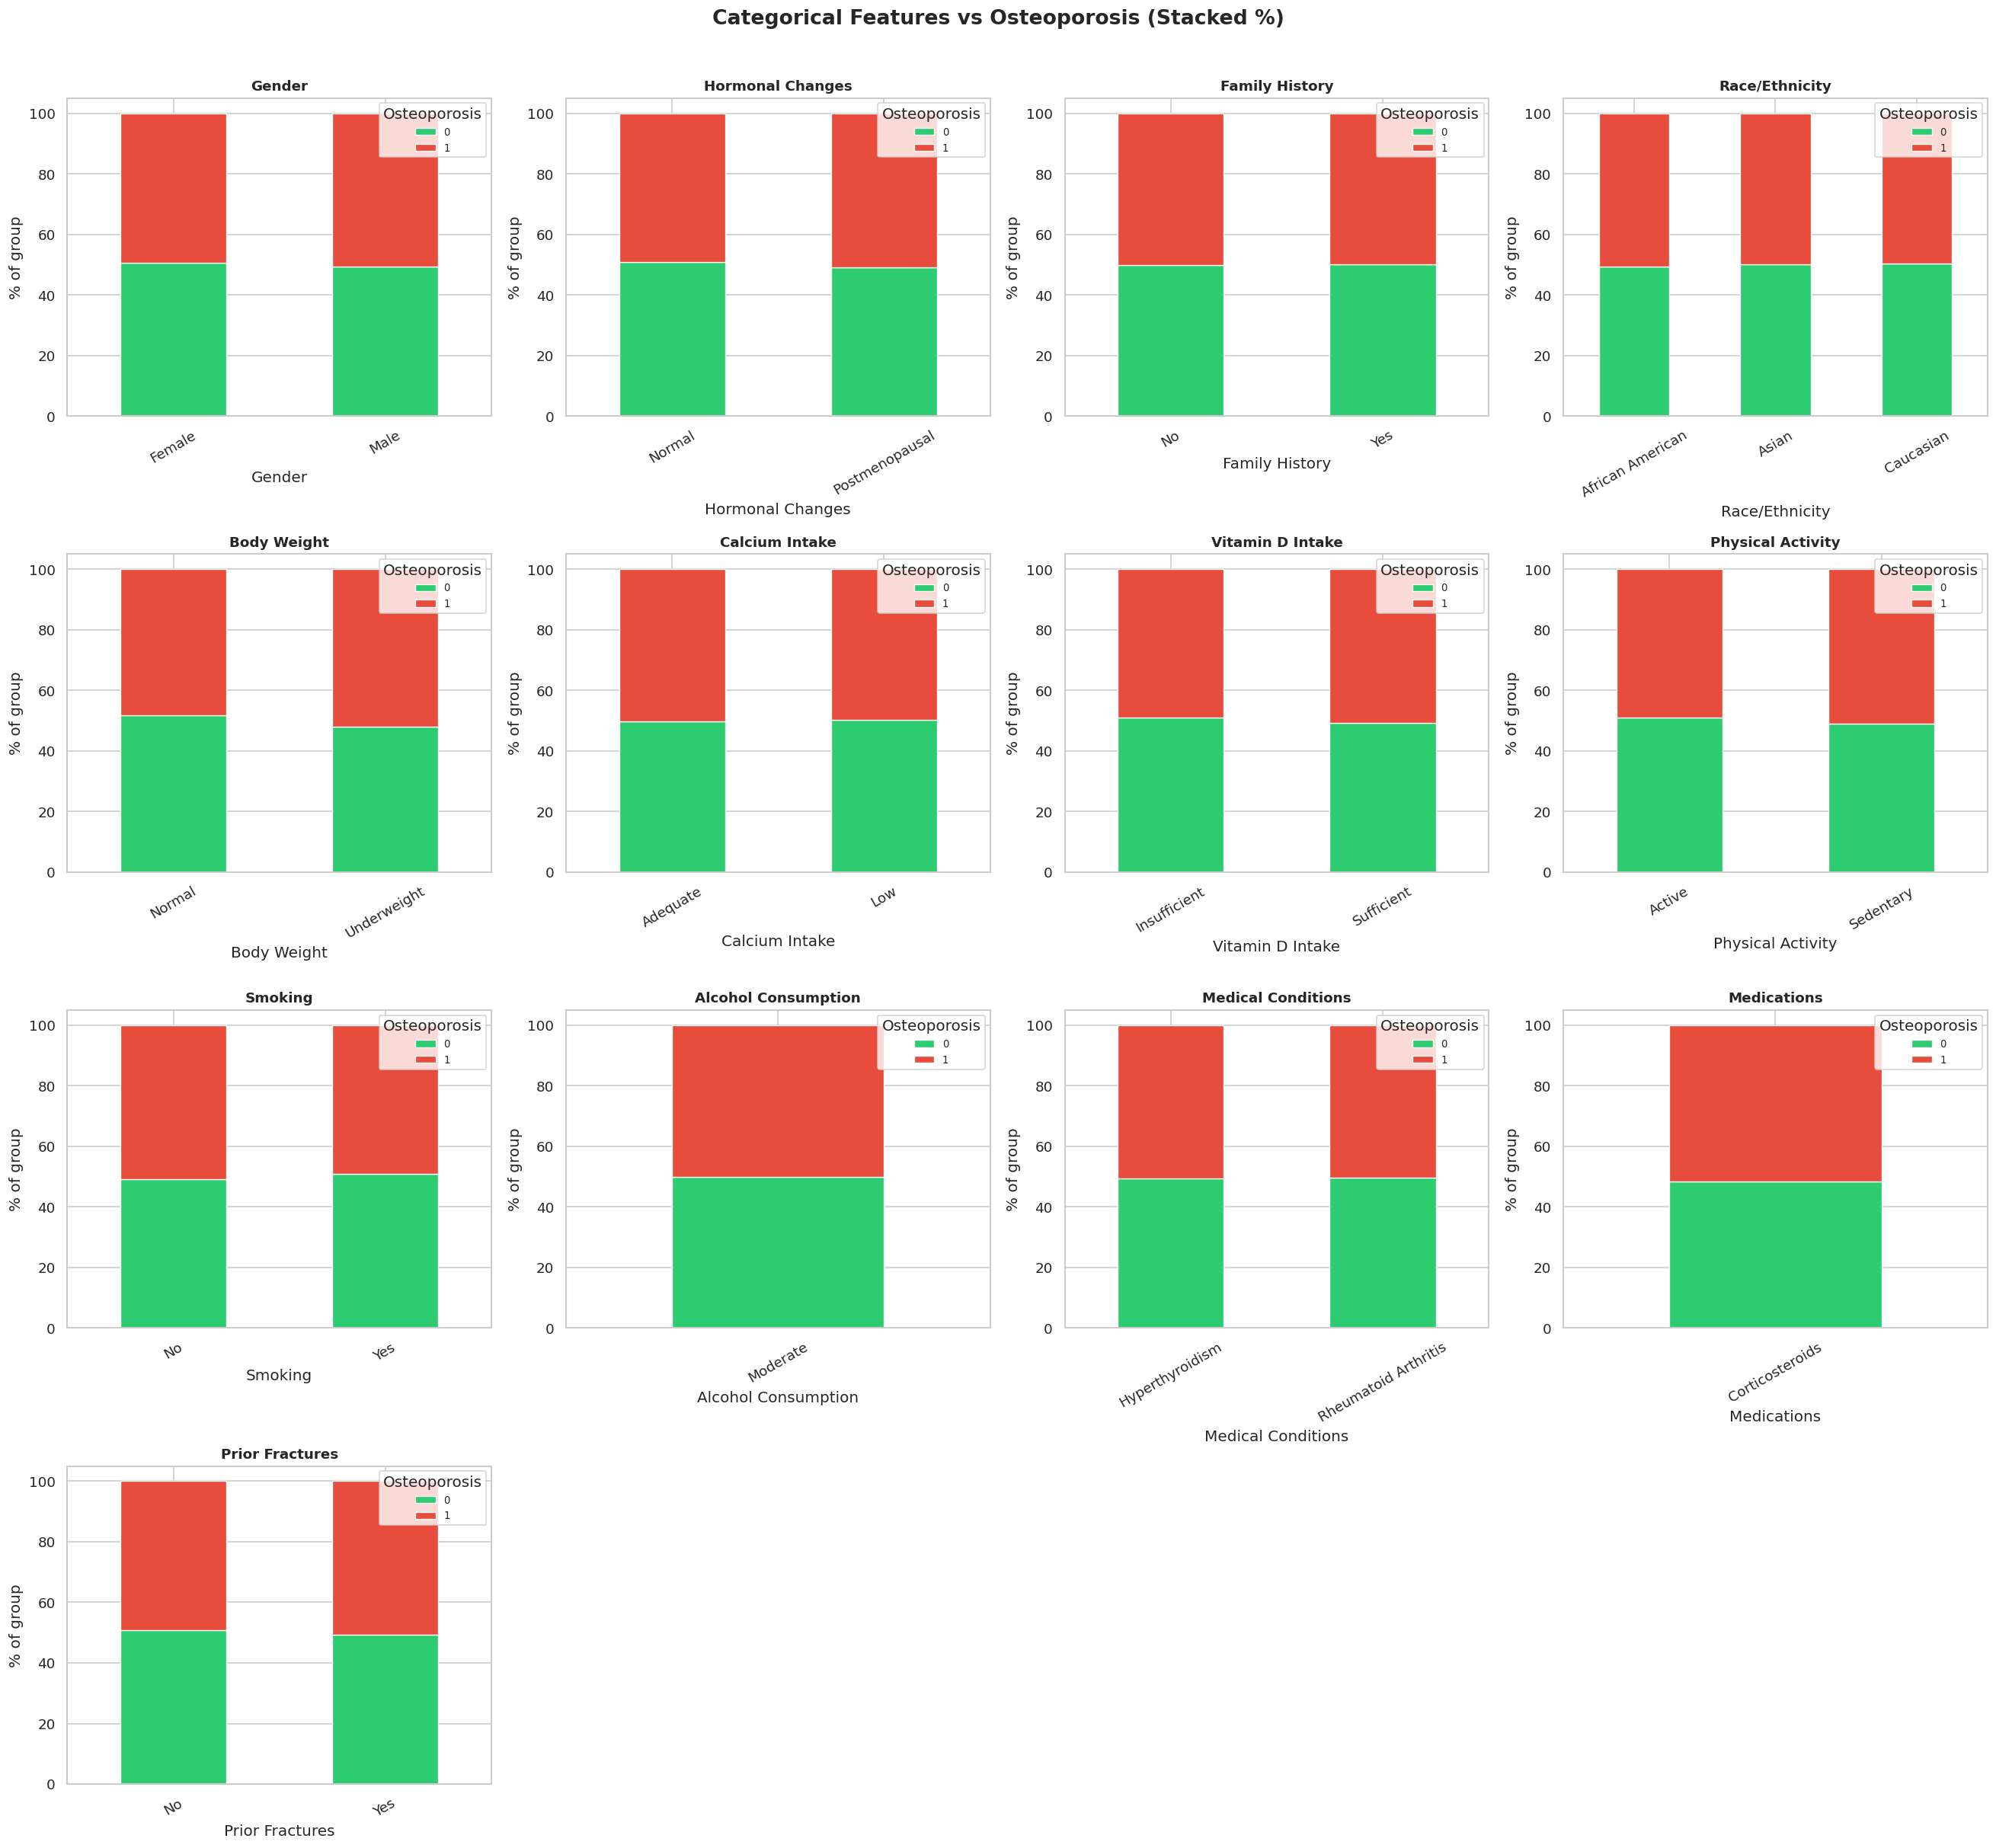

In [29]:
# --- Categorical Features vs Osteoporosis (Stacked Bar) ---
fig, axes = plt.subplots(4, 4, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Osteoporosis'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2ECC71', '#E74C3C'], edgecolor='white', linewidth=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% of group')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Osteoporosis', fontsize=8)

for k in range(len(cat_cols), len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Categorical Features vs Osteoporosis (Stacked %)', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('plot/05stacked_features_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 8 : Key Risk Factors

### Deep Diving

Target column values: [1 0]
Positive label detected: 1
Hormonal Changes: {'Normal': 49.2, 'Postmenopausal': 50.8}
Family History: {'No': 50.1, 'Yes': 49.9}
Calcium Intake: {'Adequate': 50.2, 'Low': 49.8}
Vitamin D Intake: {'Insufficient': 49.1, 'Sufficient': 50.8}
Prior Fractures: {'No': 49.2, 'Yes': 50.8}
Smoking: {'No': 50.8, 'Yes': 49.2}
Alcohol Consumption: {'Moderate': 50.1}


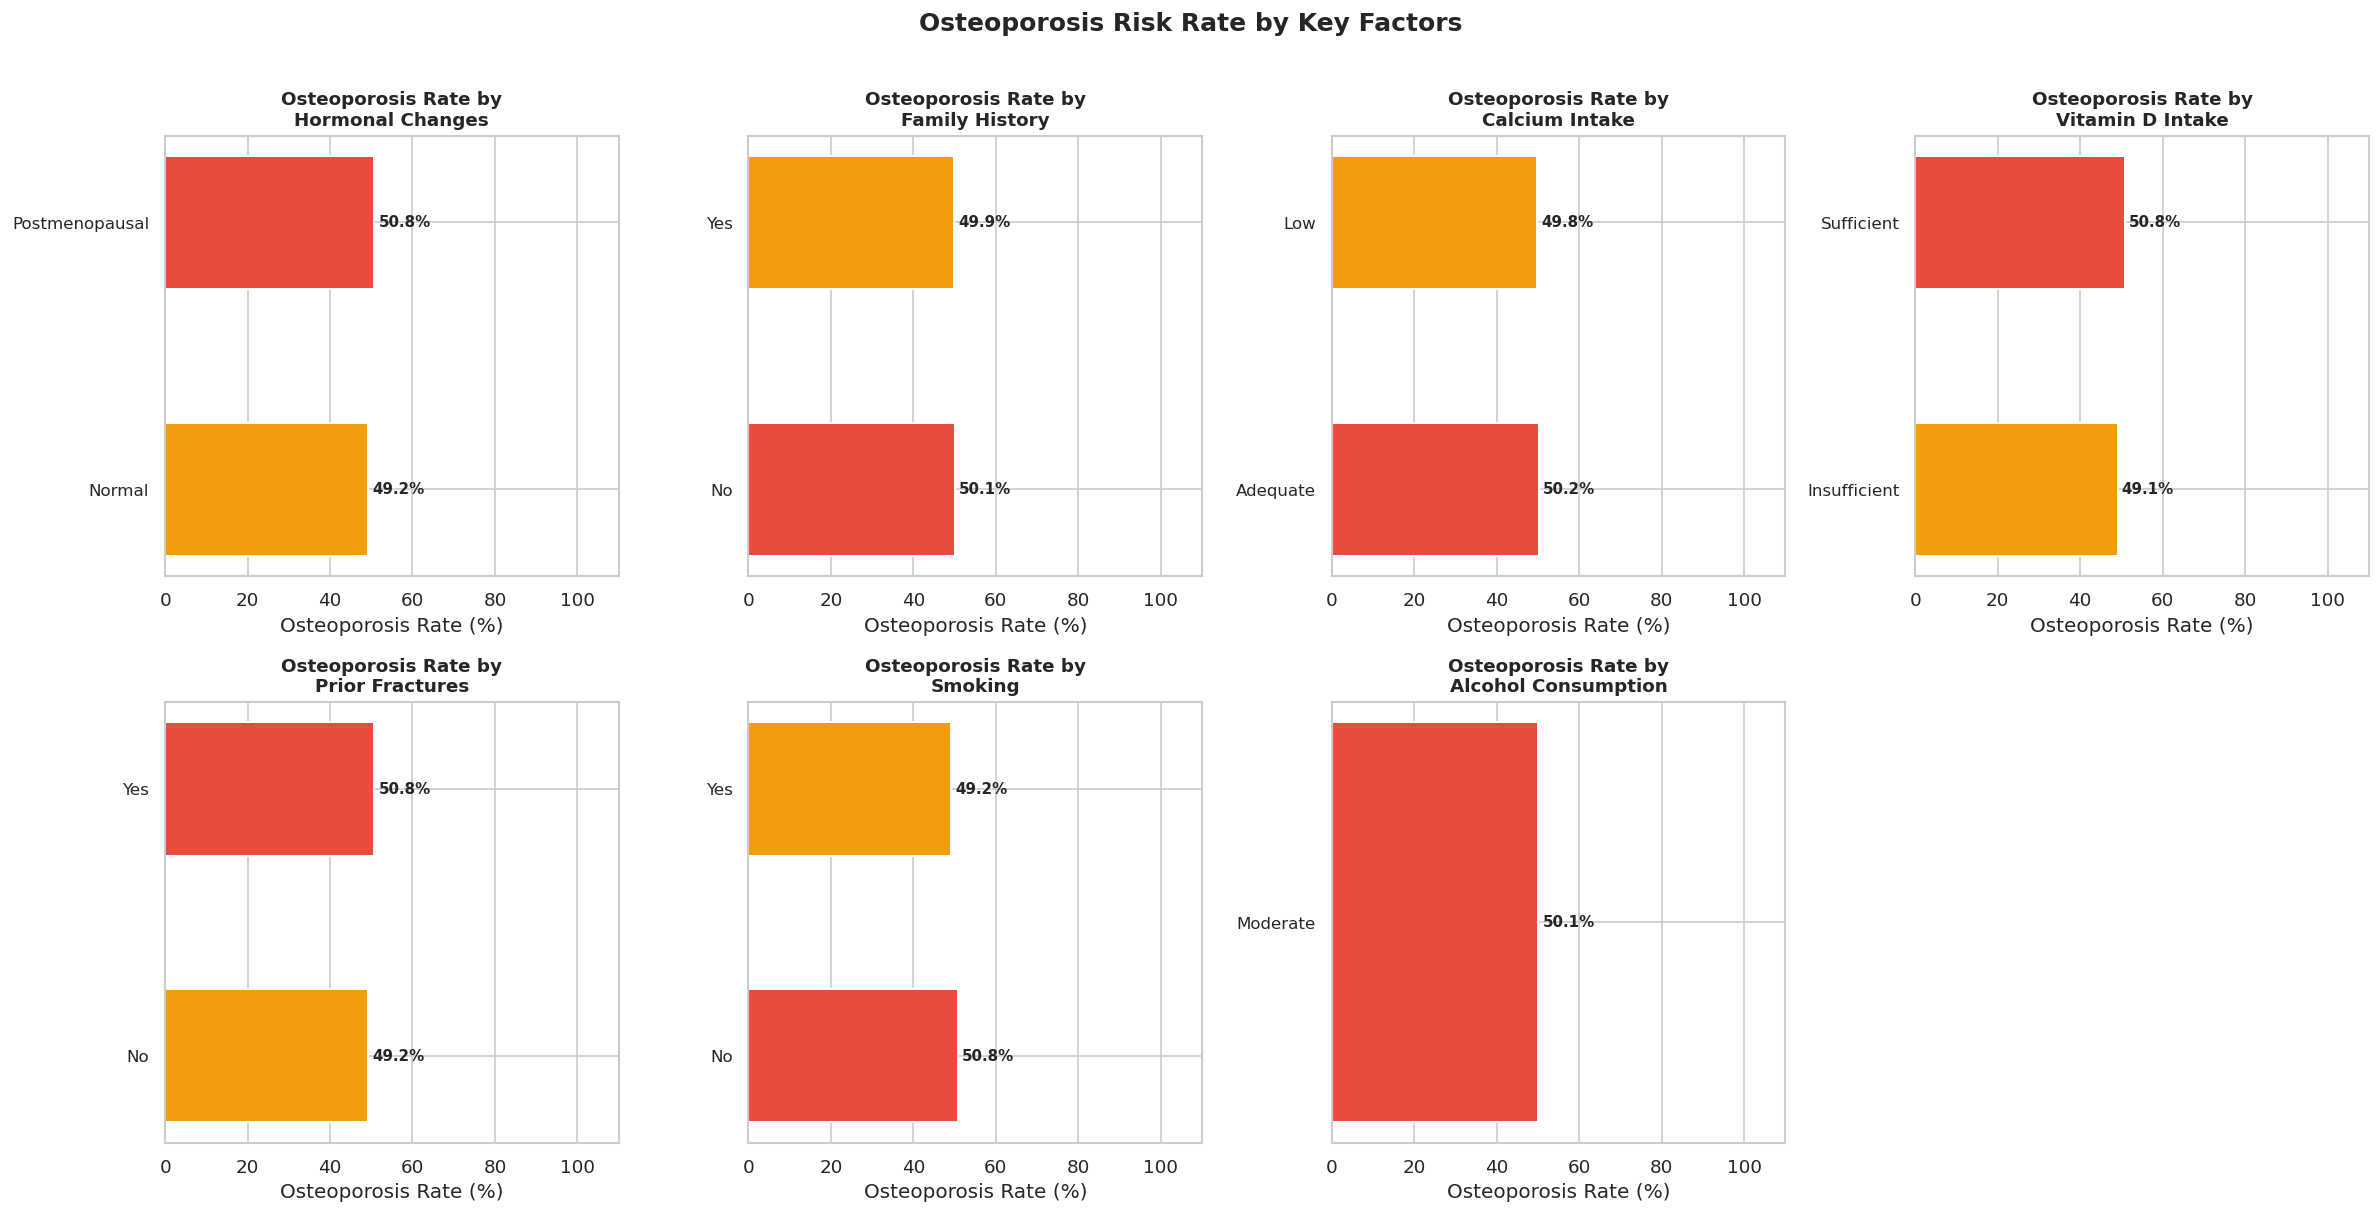

In [30]:
# --- Osteoporosis Rate per Category ---

# Step 1: Detect positive label automatically (handles Yes/No, 1/0, etc.)
target_vals = df['Osteoporosis'].unique()
pos_label = 'Yes' if 'Yes' in target_vals else (1 if 1 in target_vals else target_vals[0])
print(f'Target column values: {target_vals}')
print(f'Positive label detected: {repr(pos_label)}')

high_impact = ['Hormonal Changes', 'Family History', 'Calcium Intake',
               'Vitamin D Intake', 'Prior Fractures', 'Smoking', 'Alcohol Consumption']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(high_impact):
    # Build rates manually per group - robust to all label/dtype combos
    labels, rates = [], []
    for grp in sorted(df[col].dropna().unique(), key=str):
        subset = df[df[col] == grp]['Osteoporosis']
        r = float((subset == pos_label).sum()) / float(len(subset)) * 100.0
        labels.append(str(grp))
        rates.append(r)
    print(f'{col}: {dict(zip(labels, [round(r,1) for r in rates]))}')

    y_pos = list(range(len(labels)))
    bar_colors = ['#E74C3C' if r >= 50 else '#F39C12' if r >= 30 else '#2ECC71' for r in rates]
    axes[i].barh(y_pos, rates, color=bar_colors, edgecolor='white', linewidth=1.2, height=0.5)
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(labels, fontsize=10)
    axes[i].set_title(f'Osteoporosis Rate by\n{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Osteoporosis Rate (%)')
    axes[i].set_xlim(0, 110)
    for j, v in enumerate(rates):
        axes[i].text(v + 1, j, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Osteoporosis Risk Rate by Key Factors', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plot/06_key_risk_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 9 : Correlation & Association Anlysis

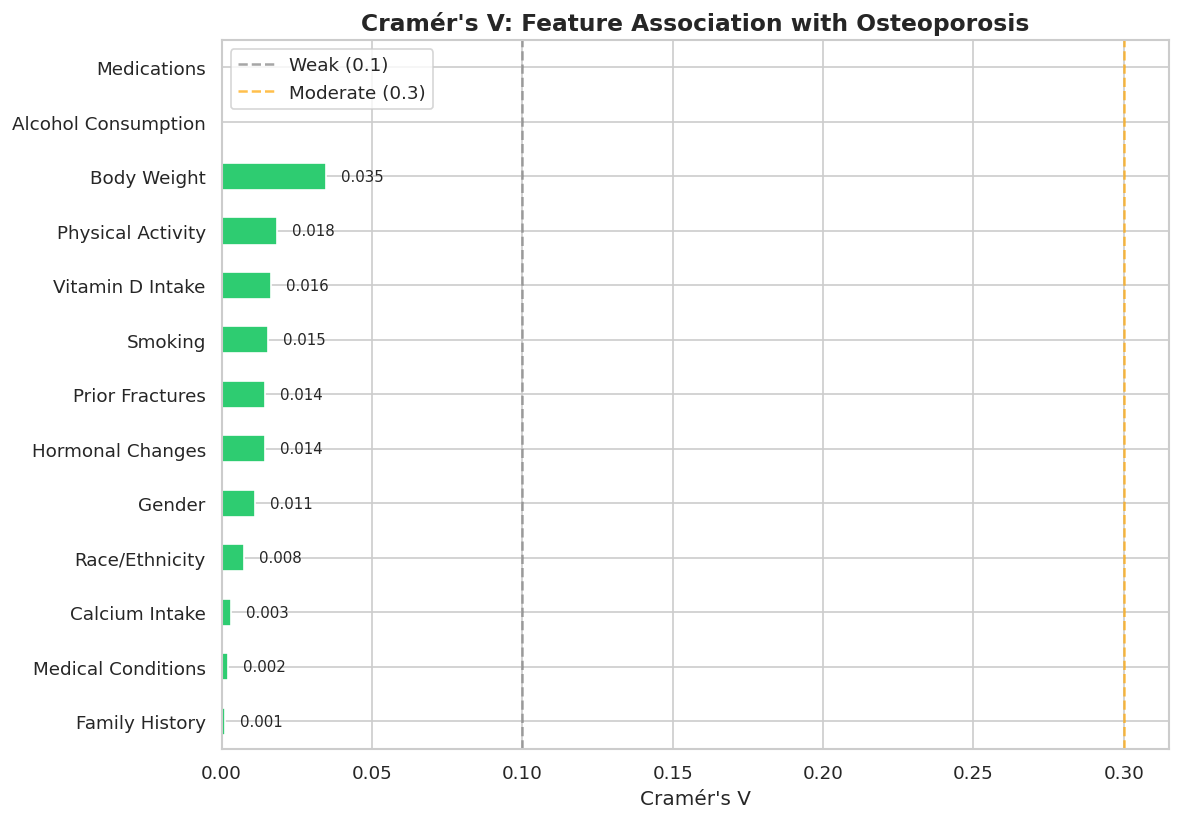


Top 5 Features Most Associated with Osteoporosis:
Body Weight          0.034771
Physical Activity    0.018403
Vitamin D Intake     0.016352
Smoking              0.015322
Prior Fractures      0.014300
dtype: float64


In [31]:
from scipy.stats import chi2_contingency

# Cramér's V for categorical associations with target
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

assoc = {}
for col in cat_cols:
    assoc[col] = cramers_v(df[col], df['Osteoporosis'])

assoc_series = pd.Series(assoc).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if v > 0.3 else '#F39C12' if v > 0.15 else '#2ECC71'
          for v in assoc_series]
assoc_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.7, label='Weak (0.1)')
ax.axvline(0.3, color='orange', linestyle='--', alpha=0.7, label='Moderate (0.3)')
ax.set_title("Cramér's V: Feature Association with Osteoporosis", fontsize=14, fontweight='bold')
ax.set_xlabel("Cramér's V")
for i, v in enumerate(assoc_series):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.legend()
plt.savefig('plot/07_Cramers_V_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

print('\nTop 5 Features Most Associated with Osteoporosis:')
print(assoc_series.sort_values(ascending=False).head())

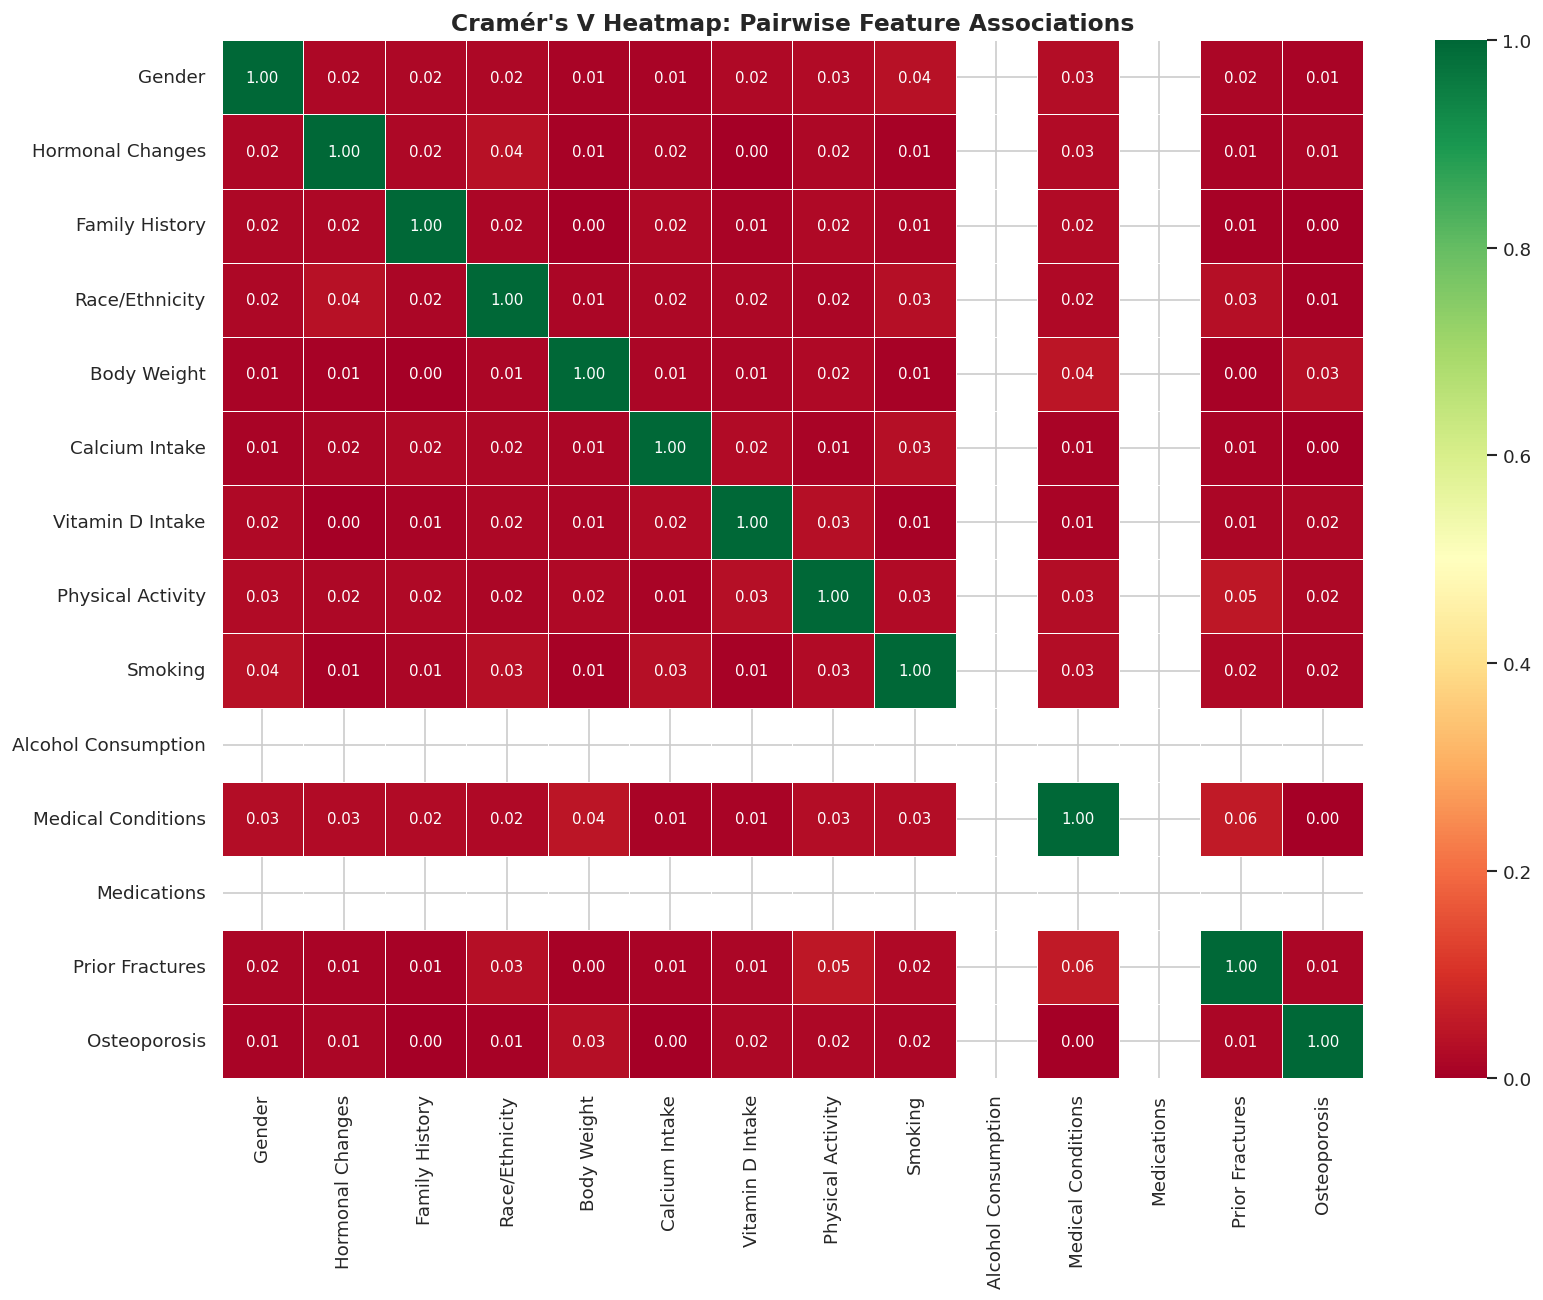

In [32]:
# --- Heatmap: Pairwise Cramér's V among all categorical features ---
all_cats = cat_cols + ['Osteoporosis']
cramer_matrix = pd.DataFrame(index=all_cats, columns=all_cats, dtype=float)

for col1 in all_cats:
    for col2 in all_cats:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title("Cramér's V Heatmap: Pairwise Feature Associations", fontsize=14, fontweight='bold')
plt.savefig('plot/08_Cramer_heatmap_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Section 10 : EDA Summary and Key insights

In [34]:
print('=' * 65)
print('   EDA KEY INSIGHTS — Osteoporosis Risk Analysis')
print('=' * 65)

total = len(df)
pos   = (df['Osteoporosis'] == 1).sum()
neg   = (df['Osteoporosis'] == 0).sum()

print(f'\n Dataset: {total} patients | Positive: {pos} ({pos/total*100:.1f}%) | Negative: {neg} ({neg/total*100:.1f}%)')
print(f'\n Top Features by Association (Cramér\'s V):')
for feat, val in assoc_series.sort_values(ascending=False).head(5).items():
    print(f'   • {feat:<30} V={val:.3f}')

print(f'\n Age Statistics:')
print(f'   • Osteoporosis=Yes: Mean Age = {yes_age.mean():.1f} yrs')
print(f'   • Osteoporosis=No:  Mean Age = {no_age.mean():.1f} yrs')
print(f'   • T-test p-value = {p_val:.4f} {"(Significant)" if p_val < 0.05 else ""}')

print(f'\n  High Risk Indicators:')
for col in ['Prior Fractures', 'Hormonal Changes', 'Family History']:
    rate = df[df['Osteoporosis'] == 1].groupby(col).size() / df.groupby(col).size() * 100
    print(f'   • {col}: {dict(rate.round(1))}')

print('\n EDA Complete — Proceed to NB2: Preprocessing & Model Training')

   EDA KEY INSIGHTS — Osteoporosis Risk Analysis

 Dataset: 1958 patients | Positive: 979 (50.0%) | Negative: 979 (50.0%)

 Top Features by Association (Cramér's V):
   • Body Weight                    V=0.035
   • Physical Activity              V=0.018
   • Vitamin D Intake               V=0.016
   • Smoking                        V=0.015
   • Prior Fractures                V=0.014

 Age Statistics:
   • Osteoporosis=Yes: Mean Age = 53.9 yrs
   • Osteoporosis=No:  Mean Age = 24.3 yrs
   • T-test p-value = 0.0000 (Significant)

  High Risk Indicators:
   • Prior Fractures: {'No': np.float64(49.2), 'Yes': np.float64(50.8)}
   • Hormonal Changes: {'Normal': np.float64(49.2), 'Postmenopausal': np.float64(50.8)}
   • Family History: {'No': np.float64(50.1), 'Yes': np.float64(49.9)}

 EDA Complete — Proceed to NB2: Preprocessing & Model Training
